In [1]:
import pandas as pd

# read data (path muhiim ah)
df = pd.read_csv("samplesuperstore.csv")

# arag data
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,1/3/2023,1/7/2023,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,1/5/2023,1/12/2023,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [2]:
# columns + types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  object 
 6   Customer Name   10194 non-null  object 
 7   Segment         10194 non-null  object 
 8   Country/Region  10194 non-null  object 
 9   City            10194 non-null  object 
 10  State/Province  10194 non-null  object 
 11  Postal Code     10194 non-null  object 
 12  Region          10194 non-null  object 
 13  Product ID      10194 non-null  object 
 14  Category        10194 non-null  object 
 15  Sub-Category    10194 non-null  object 
 16  Product Name    10194 non-null  object 
 17  Sales           10194 non-null 

In [3]:
# statistics
df.describe()

,Row ID,Sales,Quantity,Discount,Profit
count,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,228.225854,3.791838,0.155385,28.673417
std,2942.898656,619.906839,2.228317,0.206249,232.465115
min,1.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2549.250000,17.220000,2.000000,0.000000,1.760800
50%,5097.500000,53.910000,3.000000,0.200000,8.690000
75%,7645.750000,209.500000,5.000000,0.200000,29.297925
max,10194.000000,22638.480000,14.000000,0.800000,8399.976000


In [4]:
# column names
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City',
       'State/Province', 'Postal Code', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

In [5]:
# remove duplicates
df = df.drop_duplicates()

In [6]:
# check missing values
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

In [7]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [8]:
# sales by category
df.groupby('Category')['Sales'].sum()

Category
Furniture          754747.7613
Office Supplies    731893.3140
Technology         839893.2790
Name: Sales, dtype: float64

In [9]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
category_sales

Category
Technology         839893.2790
Furniture          754747.7613
Office Supplies    731893.3140
Name: Sales, dtype: float64

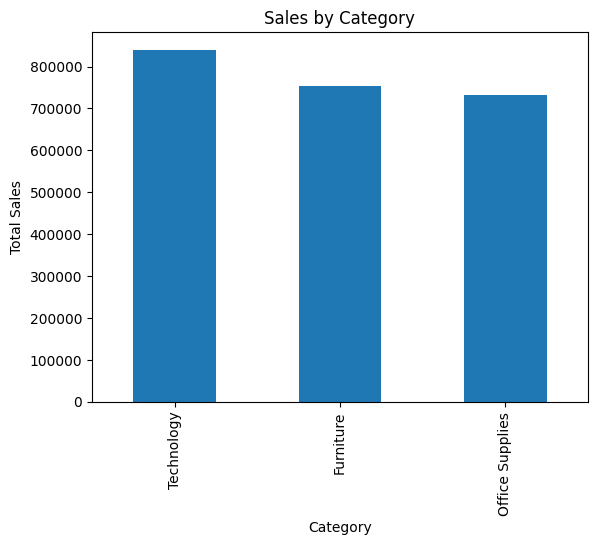

In [10]:
import matplotlib.pyplot as plt

category_sales.plot(kind='bar')
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.show()

In [11]:
top_products = df.groupby('Product Name')['Profit'].sum().sort_values(ascending=False).head(10)
top_products

Product Name
Canon imageCLASS 2200 Advanced Copier                                          25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.0390
Hewlett Packard LaserJet 3310 Copier                                            6983.8836
Canon PC1060 Personal Laser Copier                                              4570.9347
HP Designjet T520 Inkjet Large Format Printer - 24" Color                       4094.9766
Ativa V4110MDD Micro-Cut Shredder                                               3772.9461
3D Systems Cube Printer, 2nd Generation, Magenta                                3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System                      3696.2820
Ibico EPK-21 Electric Binding System                                            3345.2823
Zebra ZM400 Thermal Label Printer                                               3343.5360
Name: Profit, dtype: float64

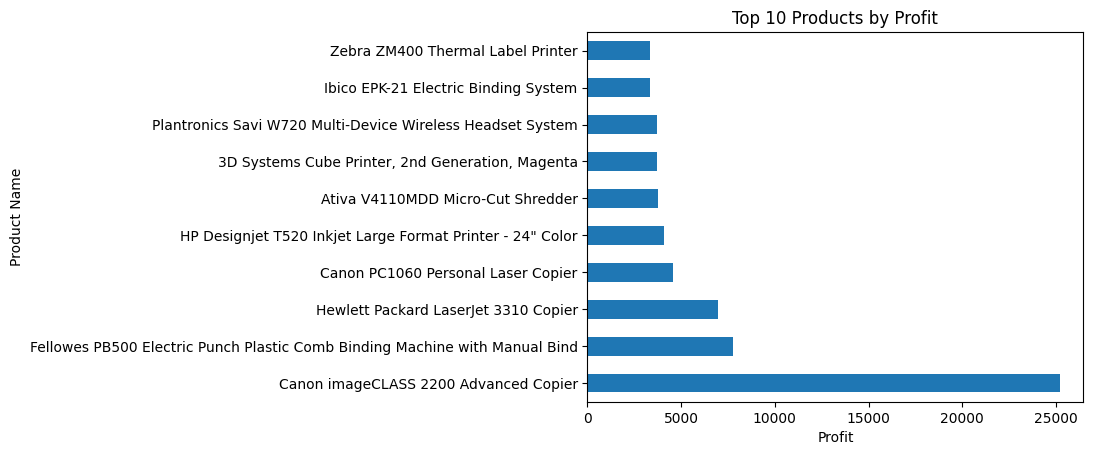

In [12]:
top_products.plot(kind='barh')
plt.title("Top 10 Products by Profit")
plt.xlabel("Profit")
plt.show()

In [13]:
df['Month'] = df['Order Date'].dt.month

monthly_sales = df.groupby('Month')['Sales'].sum()
monthly_sales

Month
1      96069.5156
2      59751.2514
3     210672.0868
4     138098.7486
5     158765.0337
6     153459.9973
7     149001.7130
8     161821.9150
9     308883.6697
10    207126.2567
11    352665.9910
12    330218.1755
Name: Sales, dtype: float64

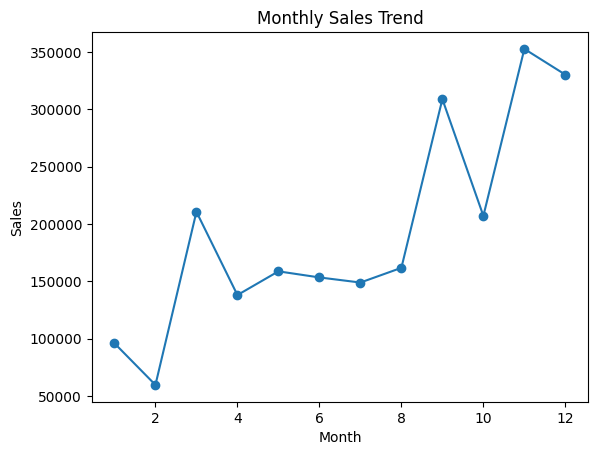

In [14]:
monthly_sales.plot(kind='line', marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

In [15]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
region_sales

Region
West       739813.6085
East       691828.1680
Central    503170.6728
South      391721.9050
Name: Sales, dtype: float64

In [16]:
df['profit_ratio'] = df['Profit'] / df['Sales']

df[['Sales','Profit','profit_ratio']].head()

,Sales,Profit,profit_ratio
0,16.448,5.5512,0.3375
1,3.540,-5.4870,-1.5500
2,11.784,4.2717,0.3625
3,272.736,-64.7748,-0.2375
4,19.536,4.8840,0.2500


In [17]:
df.groupby('Category')['profit_ratio'].mean()

Category
Furniture          0.042663
Office Supplies    0.139999
Technology         0.157680
Name: profit_ratio, dtype: float64

In [18]:
df.to_csv("cleaned_superstore.csv", index=False)

In [19]:
import sqlite3

conn = sqlite3.connect("sales.db")

print("Database created!")

Database created!


In [20]:
df.to_sql("sales", conn, if_exists="replace", index=False)

print("Data imported successfully!")

Data imported successfully!


In [21]:
query = """
SELECT Category,
       SUM(Sales) AS total_sales,
       SUM(Profit) AS total_profit
FROM sales
GROUP BY Category
ORDER BY total_sales DESC
"""

pd.read_sql(query, conn)

,Category,total_sales,total_profit
0,Technology,839893.2790,146543.3756
1,Furniture,754747.7613,19729.9956
2,Office Supplies,731893.3140,126023.4434


In [22]:
query = """
SELECT [Product Name],
       SUM(Sales) AS total_sales,
       SUM(Profit) AS total_profit
FROM sales
GROUP BY [Product Name]
ORDER BY total_profit DESC
LIMIT 10
"""

pd.read_sql(query, conn)

,Product Name,total_sales,total_profit
0,Canon imageCLASS 2200 Advanced Copier,61599.824,25199.9280
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384,7753.0390
2,Hewlett Packard LaserJet 3310 Copier,18839.686,6983.8836
3,Canon PC1060 Personal Laser Copier,11619.834,4570.9347
4,HP Designjet T520 Inkjet Large Format Printer ...,18374.895,4094.9766
5,Ativa V4110MDD Micro-Cut Shredder,7699.890,3772.9461
6,"3D Systems Cube Printer, 2nd Generation, Magenta",14299.890,3717.9714
7,Plantronics Savi W720 Multi-Device Wireless He...,9367.290,3696.2820
8,Ibico EPK-21 Electric Binding System,15875.916,3345.2823
9,Zebra ZM400 Thermal Label Printer,6965.700,3343.5360


In [23]:
query = """
SELECT Region,
       SUM(Sales) AS total_sales
FROM sales
GROUP BY Region
ORDER BY total_sales DESC
"""

pd.read_sql(query, conn)

,Region,total_sales
0,West,739813.6085
1,East,691828.1680
2,Central,503170.6728
3,South,391721.9050


In [24]:
query = """
SELECT strftime('%m', [Order Date]) AS month,
       SUM(Sales) AS total_sales
FROM sales
GROUP BY month
ORDER BY month
"""

pd.read_sql(query, conn)

,month,total_sales
0,01,96069.5156
1,02,59751.2514
2,03,210672.0868
3,04,138098.7486
4,05,158765.0337
5,06,153459.9973
6,07,149001.7130
7,08,161821.9150
8,09,308883.6697
9,10,207126.2567
